# Checkerboard Lattice Chern Band — Geometry, Topology, and QGN

**Model** (Lu, Wu, Chen, Sun & Meng, arXiv:2401.00363; original: Sun, Gu, Katsura & Das Sarma, PRL 106, 236803 (2011)):

Two-band spinless fermion model on the checkerboard lattice. Unit cell: A at $(0,0)$, B at $(1/2,1/2)$, primitive vectors $\mathbf{a}_1=(0,1)$, $\mathbf{a}_2=(1,0)$. BZ: $k_x,k_y\in[-\pi,\pi]$.

$$H(\mathbf{k}) = \begin{pmatrix} h_{AA} & h_{AB} \\ h_{AB}^* & h_{BB} \end{pmatrix}$$

$$h_{AB} = t\bigl[e^{i\phi} - e^{-i\phi}e^{-ik_x} + e^{-i\phi}e^{-ik_y} - e^{i\phi}e^{-i(k_x+k_y)}\bigr]$$

$$h_{AA/BB} = \pm 2t'(\cos k_x+\cos k_y) + 2t''(\cos(k_x+k_y)+\cos(k_x-k_y))$$

Parameters: $t=1$, $t'=1/(2+\sqrt{2})$, $t''=-1/(2+2\sqrt{2})$, $\phi=\pi/4$. Flat-band condition: $t'+|t''|=t/2$. Lower band: $W\approx0.088$, $\Delta\approx2.34$, $C=+1$.

**This notebook** applies the same analysis pipeline as `02_FCI_triangular.ipynb`:
1. Single-particle band structure + Chern number
2. Quantum geometry: Fubini-Study metric $g_{ij}$, Berry curvature $\Omega$, trace and determinant conditions
3. QGN: 2D nestability maps ($p$-$h$ CDW and $p$-$p$ pairing channels)

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from qgn.models import checkerboard_hamiltonian, CB_B1, CB_B2
from qgn.geometry import (
    projection_matrix_from_vecs,
    berry_curvature_grid, chern_number,
    fubini_study_metric_2d,
)
from qgn.core import nestability_map_2d, nesting_matrix

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

# ── Parameters ────────────────────────────────────────────────────────────────
t   = 1.0
tp  = 1.0 / (2 + np.sqrt(2))
tpp = -1.0 / (2 + 2*np.sqrt(2))
phi = np.pi / 4
print(f"t = {t},  t' = {tp:.6f},  t'' = {tpp:.6f},  φ = π/4")
print(f"Flat-band condition: t' + |t''| = {tp + abs(tpp):.6f}  (= t/2 = {t/2:.6f})")

# ── BZ sampling ──────────────────────────────────────────────────────────────
# BZ: kx,ky ∈ [−π,π]; fractional coords k1,k2 ∈ [0,1) → kx = (k1−0.5)*2π
Nk = 40
k1_arr = np.linspace(0, 1, Nk, endpoint=False)
k2_arr = np.linspace(0, 1, Nk, endpoint=False)
K1, K2 = np.meshgrid(k1_arr, k2_arr, indexing='ij')

eigvals_2d = np.zeros((Nk, Nk, 2))
eigvecs_2d = np.zeros((Nk, Nk, 2, 2), dtype=complex)

for i in range(Nk):
    for j in range(Nk):
        kx = (k1_arr[i] - 0.5) * 2 * np.pi
        ky = (k2_arr[j] - 0.5) * 2 * np.pi
        e, v = np.linalg.eigh(checkerboard_hamiltonian(np.array([kx, ky])))
        eigvals_2d[i, j] = e
        eigvecs_2d[i, j] = v

dk = 1.0 / Nk

W   = eigvals_2d[:,:,0].max() - eigvals_2d[:,:,0].min()
gap = eigvals_2d[:,:,1].min() - eigvals_2d[:,:,0].max()
print(f"\nLower band: [{eigvals_2d[:,:,0].min():.4f}, {eigvals_2d[:,:,0].max():.4f}]")
print(f"W = {W:.5f} t,  Δ = {gap:.4f} t,  M = Δ/W = {gap/W:.1f}")

t = 1.0,  t' = 0.292893,  t'' = -0.207107,  φ = π/4
Flat-band condition: t' + |t''| = 0.500000  (= t/2 = 0.500000)

Lower band: [-2.0874, -2.0000]
W = 0.08744 t,  Δ = 2.3431 t,  M = Δ/W = 26.8


## 2. Single-Particle Band Structure and Topology

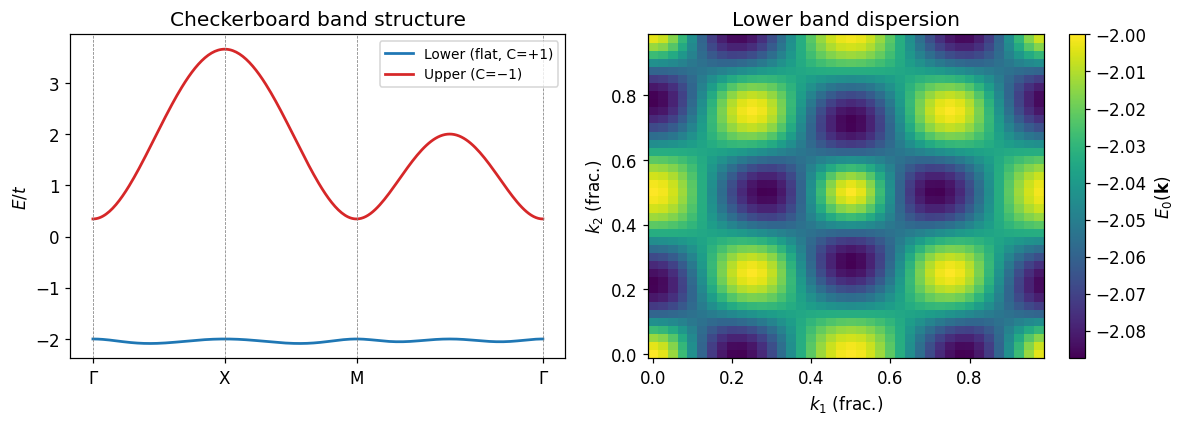

Chern number (FHS): C = 1.000
Lower band: W = 0.08744 t,  Δ = 2.3431 t,  M = Δ/W = 26.8

The extremely large flatness ratio M ≈ 27 makes this one of the most
ideal Chern flat bands known, far exceeding the FCI triangular model (M ≈ 18).


In [2]:
# High-symmetry path: Γ(0,0) → X(π,0) → M(π,π) → Γ  (square BZ)
N_seg = 80
Gamma = np.array([0.0, 0.0])
X_pt  = np.array([np.pi, 0.0])
M_pt  = np.array([np.pi, np.pi])

def make_kpath(pts, N):
    segs = []
    for p0, p1 in zip(pts[:-1], pts[1:]):
        segs.append(np.outer(np.linspace(0,1,N,endpoint=False), p1-p0) + p0)
    segs.append(pts[-1:])
    return np.vstack(segs)

k_path = make_kpath([Gamma, X_pt, M_pt, Gamma], N_seg)
k_dist = np.concatenate([[0], np.cumsum(np.linalg.norm(np.diff(k_path,axis=0),axis=1))])
ticks  = [0,
          np.linalg.norm(X_pt - Gamma),
          np.linalg.norm(X_pt - Gamma) + np.linalg.norm(M_pt - X_pt),
          k_dist[-1]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Band structure
ax = axes[0]
Es = np.array([np.linalg.eigvalsh(checkerboard_hamiltonian(k)) for k in k_path])
for n, col in enumerate(['tab:blue','tab:red']):
    ax.plot(k_dist, Es[:,n], color=col, lw=1.8,
            label=['Lower (flat, C=+1)','Upper (C=−1)'][n])
for xp in ticks:
    ax.axvline(xp, color='gray', lw=0.5, ls='--')
ax.set_xticks(ticks); ax.set_xticklabels(['Γ','X','M','Γ'])
ax.set_ylabel('$E/t$'); ax.set_title('Checkerboard band structure')
ax.legend(fontsize=9)

# Dispersion on BZ
ax2 = axes[1]
pcm = ax2.pcolormesh(K1, K2, eigvals_2d[:,:,0], cmap='viridis', shading='auto')
plt.colorbar(pcm, ax=ax2, label='$E_0(\\mathbf{k})$')
ax2.set_xlabel('$k_1$ (frac.)'); ax2.set_ylabel('$k_2$ (frac.)')
ax2.set_title('Lower band dispersion')

plt.tight_layout(); plt.show()

# Chern number
C = chern_number(eigvecs_2d, flat_bands=[0])
print(f"Chern number (FHS): C = {C:.3f}")
print(f"Lower band: W = {W:.5f} t,  Δ = {gap:.4f} t,  M = Δ/W = {gap/W:.1f}")
print(f"\nThe extremely large flatness ratio M ≈ {gap/W:.0f} makes this one of the most")
print(f"ideal Chern flat bands known, far exceeding the FCI triangular model (M ≈ 18).")

## 3. Quantum Geometry: Fubini-Study Metric and Berry Curvature

Same analysis as the FCI triangular model. Ideal Chern-band conditions:
- **Trace**: $g_{11}+g_{22}\ge|\Omega|$ (equality = ideal)
- **Determinant**: $\det g = (\Omega/2)^2$ (isotropic metric = LLL analog)

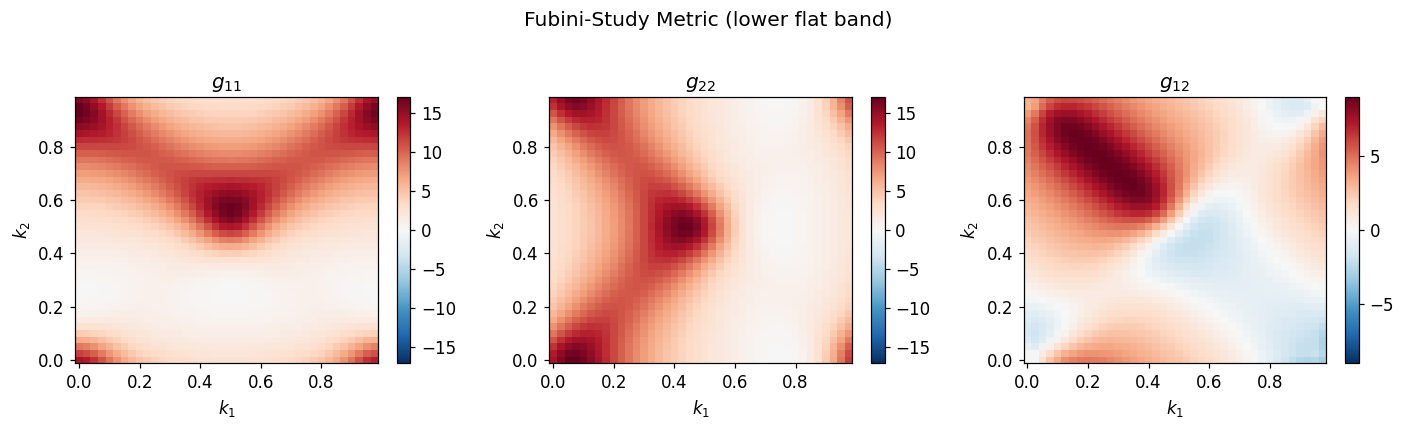

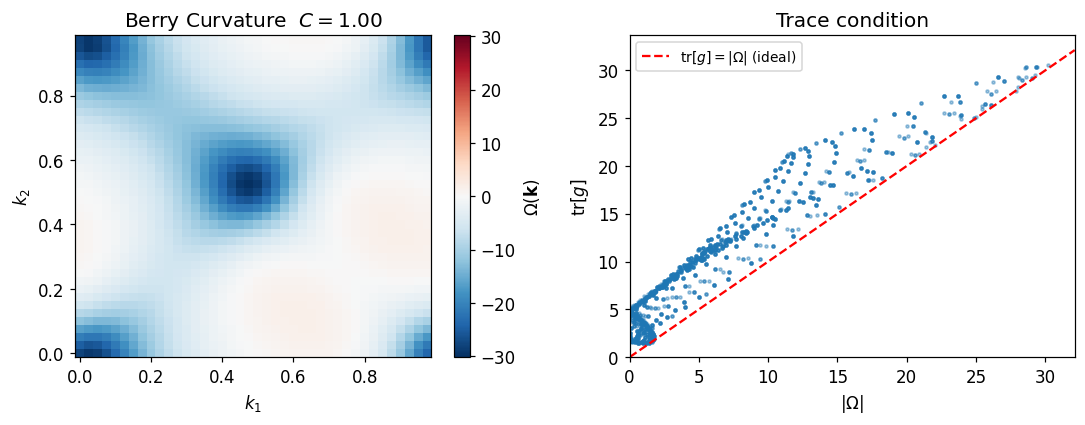

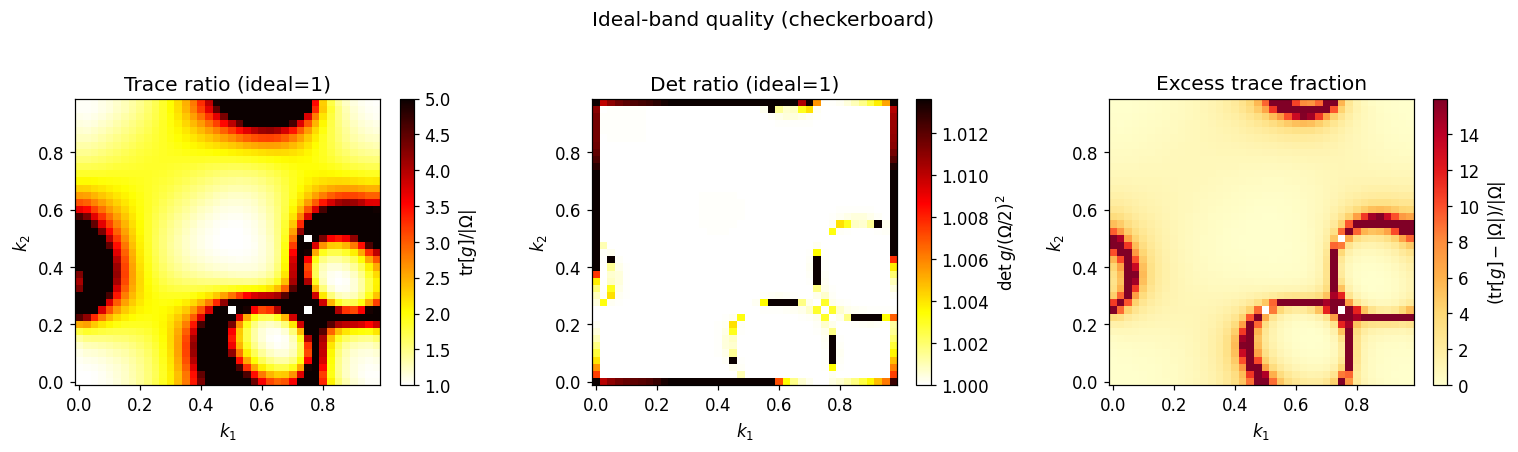

Trace condition satisfied everywhere: True
Det condition satisfied everywhere:   True

Trace ratio  tr[g]/|Ω|:  mean=5.5188,  max=297.9400
Det   ratio  det[g]/(Ω/2)²:  mean=1.0385,  95th=1.0136

Compare with FCI triangular: trace mean≈1.19, det mean≈1.00


In [3]:
g11, g12, g22 = fubini_study_metric_2d(eigvecs_2d, flat_bands=[0], dk1=dk, dk2=dk)
Omega = berry_curvature_grid(eigvecs_2d, flat_bands=[0], dk1=dk, dk2=dk)

tr_g  = g11 + g22
det_g = g11*g22 - g12**2

with np.errstate(divide='ignore', invalid='ignore'):
    trace_ratio = np.where(np.abs(Omega) > 1e-8, tr_g / np.abs(Omega), np.nan)
    det_ratio   = np.where((Omega/2)**2 > 1e-12, det_g / (Omega/2)**2, np.nan)
    excess      = np.where(np.abs(Omega) > 1e-8, (tr_g - np.abs(Omega))/np.abs(Omega), np.nan)

C_fhs = chern_number(eigvecs_2d, flat_bands=[0])

# ── Metric components ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (data, label) in zip(axes, [(g11,'$g_{11}$'),(g22,'$g_{22}$'),(g12,'$g_{12}$')]):
    vmax = np.abs(data).max()
    pcm = ax.pcolormesh(K1, K2, data, cmap='RdBu_r', shading='auto', vmin=-vmax, vmax=vmax)
    plt.colorbar(pcm, ax=ax)
    ax.set_xlabel('$k_1$'); ax.set_ylabel('$k_2$'); ax.set_title(label)
plt.suptitle("Fubini-Study Metric (lower flat band)", y=1.02); plt.tight_layout(); plt.show()

# ── Berry curvature + scatter ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vmax = np.abs(Omega).max()
pcm = axes[0].pcolormesh(K1, K2, Omega, cmap='RdBu_r', shading='auto', vmin=-vmax, vmax=vmax)
plt.colorbar(pcm, ax=axes[0], label='$\\Omega(\\mathbf{k})$')
axes[0].set_xlabel('$k_1$'); axes[0].set_ylabel('$k_2$')
axes[0].set_title(f'Berry Curvature  $C={C_fhs:.2f}$')

ax2 = axes[1]
absO = np.abs(Omega.ravel()); trg = tr_g.ravel()
mask = absO > 0.01
ax2.scatter(absO[mask], trg[mask], s=4, alpha=0.4, color='tab:blue')
xlim = max(absO.max(), trg.max())*1.05
ax2.plot([0,xlim],[0,xlim],'r--',lw=1.5,label='$\\mathrm{tr}[g]=|\\Omega|$ (ideal)')
ax2.set_xlabel('$|\\Omega|$'); ax2.set_ylabel('$\\mathrm{tr}[g]$')
ax2.set_title('Trace condition'); ax2.legend(fontsize=9)
ax2.set_xlim(0,xlim); ax2.set_ylim(0,trg.max()*1.1)
plt.tight_layout(); plt.show()

# ── Trace/det condition maps ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pcm = axes[0].pcolormesh(K1,K2,trace_ratio,cmap='hot_r',shading='auto',vmin=1,vmax=5)
plt.colorbar(pcm,ax=axes[0],label='$\\mathrm{tr}[g]/|\\Omega|$')
axes[0].set_title('Trace ratio (ideal=1)')

pcm2 = axes[1].pcolormesh(K1,K2,det_ratio,cmap='hot_r',shading='auto',vmin=1,
                          vmax=np.nanpercentile(det_ratio,95))
plt.colorbar(pcm2,ax=axes[1],label='$\\det g/(\\Omega/2)^2$')
axes[1].set_title('Det ratio (ideal=1)')

pcm3 = axes[2].pcolormesh(K1,K2,excess,cmap='YlOrRd',shading='auto',vmin=0,
                          vmax=np.nanpercentile(excess,95))
plt.colorbar(pcm3,ax=axes[2],label='$(\\mathrm{tr}[g]-|\\Omega|)/|\\Omega|$')
axes[2].set_title('Excess trace fraction')
for ax in axes: ax.set_xlabel('$k_1$'); ax.set_ylabel('$k_2$')
plt.suptitle("Ideal-band quality (checkerboard)", y=1.02); plt.tight_layout(); plt.show()

print(f"Trace condition satisfied everywhere: {np.all(tr_g >= np.abs(Omega) - 1e-6)}")
print(f"Det condition satisfied everywhere:   {np.all(det_g >= (Omega/2)**2 - 1e-10)}")
print(f"\nTrace ratio  tr[g]/|Ω|:  mean={np.nanmean(trace_ratio):.4f},  max={np.nanmax(trace_ratio):.4f}")
print(f"Det   ratio  det[g]/(Ω/2)²:  mean={np.nanmean(det_ratio):.4f},  95th={np.nanpercentile(det_ratio,95):.4f}")
print(f"\nCompare with FCI triangular: trace mean≈1.19, det mean≈1.00")

## 4. Quantum Geometric Nesting (QGN)

2D nestability $\tilde\omega_0^Q$ for the p-h (CDW) and p-p (pairing) channels.
The paper's FQAHS smectic order appears at $\mathbf{Q}=(\pi,0)$ or $(0,\pi)$, breaking $C_4$ to $C_2$.
We check whether QGN selects these wave vectors geometrically.

Computing 2D p-h nestability map ...
Computing 2D p-p nestability map ...


Done.



p-h  Q=(0,0): ω₀ = 0.000000  (trivially 0 — N=I null vector)
p-h  smectic Q=(π,0) [q1_frac=0.5]: ω₀ = 0.3777
p-p  min ω₀ = 0.1412  at Q_frac = [0. 0.]

p-p null vector:  antisymmetric=False,  symmetric=True
★ p-p null vector SYMMETRIC (trivial). No pairing order geometrically favored.


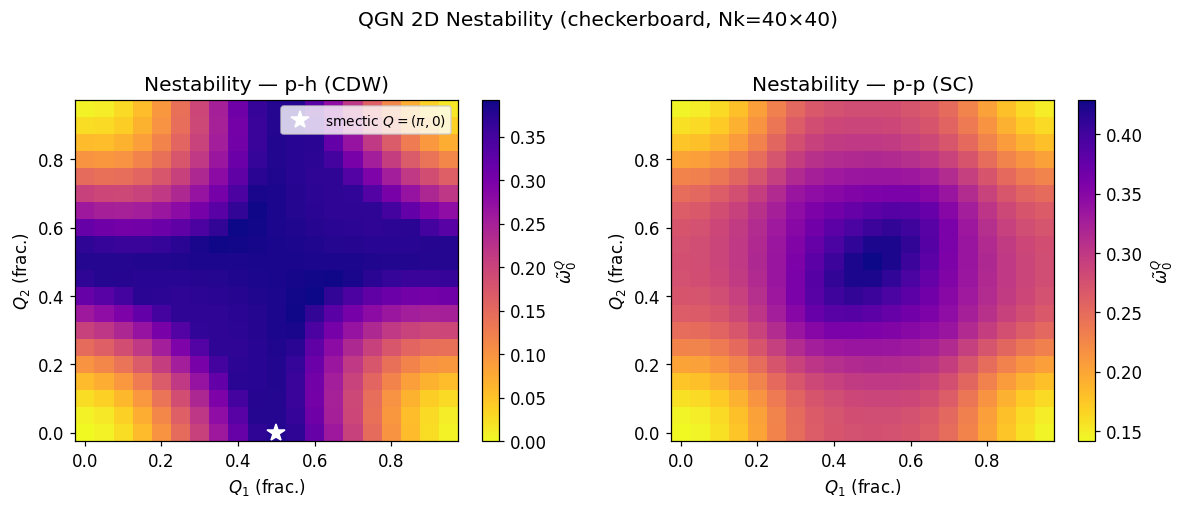

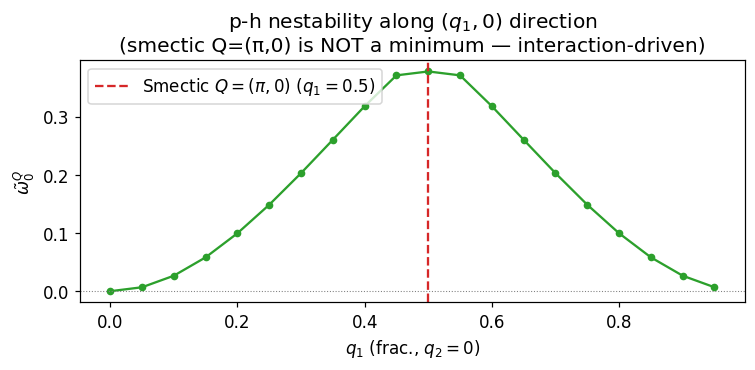


p-h nestability at smectic Q=(π,0): ω₀ = 0.3777
→ The FQAHS smectic at Q=(π,0) is NOT geometrically favored by QGN.
→ It is selected by the V₃ NNNN repulsive interaction (couples at the (π,0) distance).
→ QGN geometry does not select this Q over any other nonzero Q.


In [4]:
print("Computing 2D p-h nestability map ...")
omega_ph, q1_ph, q2_ph = nestability_map_2d(eigvecs_2d, channel='ph')
print("Computing 2D p-p nestability map ...")
omega_pp, q1_pp, q2_pp = nestability_map_2d(eigvecs_2d, channel='pp')
print("Done.")

# p-h: Q=0 is trivially 0 (N=I always a null vector).
# Physically interesting: value at smectic Q=(π,0) = q1_frac=0.5, q2_frac=0
# In fractional coords: Q_phys = (π,0) → shift dq1 = Nk//4
dq_smectic = Nk // 4   # Q=(π,0): iq1=Nk//4 → q1_frac=0.5, Q_x=π
omega_smectic = omega_ph[dq_smectic, 0]

# p-p minimum (non-trivial)
i1_pp, i2_pp = np.unravel_index(np.argmin(omega_pp), omega_pp.shape)
Q_pp_frac = np.array([q1_pp[i1_pp], q2_pp[i2_pp]])

# Check p-p null vector at its minimum
P2 = projection_matrix_from_vecs(eigvecs_2d.reshape(Nk*Nk,2,2),[0]).reshape(Nk,Nk,2,2)
Q2m = np.eye(2,dtype=complex)[None,None] - P2
P_p = np.roll(np.roll(P2, i1_pp,0), i2_pp,1); P_m = np.roll(np.roll(P2,-i1_pp,0),-i2_pp,1)
Q_p = np.roll(np.roll(Q2m,i1_pp,0), i2_pp,1); Q_m = np.roll(np.roll(Q2m,-i1_pp,0),-i2_pp,1)
Pi_pp = ((np.einsum('...ab,...cd->...adbc',P_p.conj(),Q_m)
        + np.einsum('...ab,...cd->...adbc',Q_p.conj(),P_m)).mean(axis=(0,1))).reshape(4,4)
Pi_pp = (Pi_pp+Pi_pp.conj().T)/2
evals_pp, evecs_pp = np.linalg.eigh(Pi_pp)
null_pp = evecs_pp[:,0].reshape(2,2)
is_antisym = np.allclose(null_pp+null_pp.T, 0, atol=1e-3)
is_sym     = np.allclose(null_pp-null_pp.T, 0, atol=1e-3)

print(f"\np-h  Q=(0,0): ω₀ = {omega_ph[0,0]:.6f}  (trivially 0 — N=I null vector)")
print(f"p-h  smectic Q=(π,0) [q1_frac=0.5]: ω₀ = {omega_smectic:.4f}")
print(f"p-p  min ω₀ = {omega_pp.min():.4f}  at Q_frac = {Q_pp_frac}")
print(f"\np-p null vector:  antisymmetric={is_antisym},  symmetric={is_sym}")
if is_sym and not is_antisym:
    print("★ p-p null vector SYMMETRIC (trivial). No pairing order geometrically favored.")

# ── Plot nestability maps ─────────────────────────────────────────────────────
Qph_m, Qph_n = np.meshgrid(q1_ph, q2_ph, indexing='ij')
Qpp_m, Qpp_n = np.meshgrid(q1_pp, q2_pp, indexing='ij')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, omega, Qm, Qn, label in [
        (axes[0], omega_ph, Qph_m, Qph_n, 'p-h (CDW)'),
        (axes[1], omega_pp, Qpp_m, Qpp_n, 'p-p (SC)')]:
    pcm = ax.pcolormesh(Qm, Qn, omega, cmap='plasma_r', shading='auto')
    plt.colorbar(pcm, ax=ax, label='$\\tilde{\\omega}_0^Q$')
    ax.set_xlabel('$Q_1$ (frac.)'); ax.set_ylabel('$Q_2$ (frac.)')
    ax.set_title(f'Nestability — {label}')

# Mark smectic Q on p-h map
axes[0].plot(0.5, 0.0, 'w*', ms=12, label='smectic $Q=(\\pi,0)$')
axes[0].legend(fontsize=9)

plt.suptitle(f"QGN 2D Nestability (checkerboard, Nk={Nk}×{Nk})", y=1.02)
plt.tight_layout(); plt.show()

# ── Nestability along q1 direction (q2=0) crossing smectic Q ─────────────────
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(q1_ph, omega_ph[:,0], 'o-', ms=4, color='tab:green')
ax.axvline(0.5, color='tab:red', ls='--', lw=1.5, label='Smectic $Q=(\\pi,0)$ ($q_1=0.5$)')
ax.axhline(0, color='gray', ls=':', lw=0.7)
ax.set_xlabel('$q_1$ (frac., $q_2=0$)'); ax.set_ylabel('$\\tilde{\\omega}_0^Q$')
ax.set_title('p-h nestability along $(q_1,0)$ direction\n(smectic Q=(π,0) is NOT a minimum — interaction-driven)')
ax.legend(); plt.tight_layout(); plt.show()

print(f"\np-h nestability at smectic Q=(π,0): ω₀ = {omega_smectic:.4f}")
print(f"→ The FQAHS smectic at Q=(π,0) is NOT geometrically favored by QGN.")
print(f"→ It is selected by the V₃ NNNN repulsive interaction (couples at the (π,0) distance).")
print(f"→ QGN geometry does not select this Q over any other nonzero Q.")